# Домашнее задание по теме «Оценка моделей и подбор гиперпараметров»

В этом задании ты продолжишь работу с датасетом Student Depression и закрепишь:
- подбор гиперпараметров с помощью k-fold кросс-валидации;
- интервальную оценку качества с помощью бутстреп.


> ### Правила домашнего задания
>
>1. Нельзя удалять существующие ячейки кода.
>
>2. Можно добавлять и дописывать свои ячейки.
>
>3. Место, куда тебе нужно написать код, помечается комментарием.
>
> 4. Ответ без кода, который подтвердит твоё решение, не засчитывается. Исключение — задачи и вопросы, где код не требуется и нужно сделать вывод из известных данных.
>
> 5. Код должен быть работоспособным. У проверяющих должна быть возможность воспроизвести все полученные результаты.
>
> 6. Все графики подписывай так, чтобы можно было легко понять их суть. Избегай слишком мелкого или крупного текста, подписывай оси на одном языке.
>
> 7. Фиксируй seed random для воспроизводимости результатов.


## Установка библиотек

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as sps
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.tree import DecisionTreeClassifier

from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore")

SEED = 21
np.random.seed(SEED)

## Задание 1 [0,5 балла]

Подготовь данные для обучения моделей на датасете Student Depression, который был в прошлом домашнем задании.

1. Скачай датасет и загрузи его в `df` — **[0,1 балла]**.
2. Сделай `id` индексом или удали колонку `id` — **[0,1 балла]**.
3. Обработай пропуски (например, удалением строк или заполнением) — **[0,1 балла]**.
4. Закодируй категориальные признаки (например, `pd.get_dummies`) и получи `df_encoded` — **[0,1 балла]**.
5. Отдели таргет (`Depression`) от признаков и посчитай долю студентов с депрессией — **[0,1 балла]**.

In [ ]:
# Скачай датасет
!gdown 1VulOU7P9Tfisb4nazeFxny__5zJ9zPkd

Downloading...
From: https://drive.google.com/uc?id=1VulOU7P9Tfisb4nazeFxny__5zJ9zPkd
To: /content/Student Depression Dataset.csv
100% 2.81M/2.81M [00:00<00:00, 232MB/s]


In [ ]:
df = pd.read_csv("Student Depression Dataset.csv")
df = df.set_index("id")

df["Gender"] = LabelEncoder().fit_transform(df["Gender"])
df["City"] = LabelEncoder().fit_transform(df["City"])
df["Profession"] = LabelEncoder().fit_transform(df["Profession"])
df["Sleep Duration"] = OrdinalEncoder(
    categories=[['Less than 5 hours', '5-6 hours', '7-8 hours', 'More than 8 hours', 'Others']]
).fit_transform(df[["Sleep Duration"]])
df["Dietary Habits"] = LabelEncoder().fit_transform(df["Dietary Habits"])
df["Degree"] = LabelEncoder().fit_transform(df["Degree"])
df["Have you ever had suicidal thoughts ?"] = LabelEncoder().fit_transform(df["Have you ever had suicidal thoughts ?"])
df["Family History of Mental Illness"] = LabelEncoder().fit_transform(df["Family History of Mental Illness"])
df["Financial Stress"] = df["Financial Stress"].fillna(
    df["Work/Study Hours"] * df["Study Satisfaction"] /
    df["Study Satisfaction"].max() / df["Work/Study Hours"].max()
    * df["Financial Stress"].max()
)
df_encoded = df.copy()

X, y = df_encoded.drop("Depression", axis=1), df_encoded["Depression"]

## Задание 2 [0,5 балла]

Обучи две модели машинного обучения. Можешь взять те же модели, что и в предыдущем домашнем задании.

1. Разбей датасет на train и test.
2. Обучи две модели.
3. Посчитай `Accuracy` на train и test для каждой модели. Являются ли какие-то из них переобученными? Оставь ответ в текстовом блоке.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15)

In [ ]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)
print(f"Logistic Regression results:")
print(f"\t -train: {accuracy_score(y_train, lr_model.predict(X_train))}")
print(f"\t -test: {accuracy_score(y_test, y_pred)}")

Logistic Regression results:
	 -train: 0.8462998102466793
	 -test: 0.8506927854753942


In [ ]:
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)
y_pred = dt_model.predict(X_test)
print(f"Decision Tree results:")
print(f"\t -train: {accuracy_score(y_train, dt_model.predict(X_train))}")
print(f"\t -test: {accuracy_score(y_test, y_pred)}")

Decision Tree results:
	 -train: 1.0
	 -test: 0.7666029622551361


Из приведенных выше показателей можно сделать 2 вывода:
1. `Logistic Regression` не переобучилась, при этом показала довольно хороший `accuracy`, что на тренировочной, что на тестовой.
2. Дерево решений просто тотально перебучилось `accuracy=1.0`, поэтому неудивительно, что результаты на тестовой сильно хуже, и хуже чем в первом случае.

## Задание 3 [3 балла]

Подбери гиперпараметры для обеих моделей с помощью k-fold кросс-валидации.

1. Задай сетки гиперпараметров — **[1 балл]**.
2. Запусти `GridSearchCV` (или `RandomizedSearchCV`) с `cv=5` — **[1 балл]**.
3. Выведи: лучшие гиперпараметры, среднее качество по фолдам и стандартное отклонение — **[1 балл]**.

Подсказка. Можно попробовать перебрать следующие параметры.

* Деревья решений: `max_depth`, `min_samples_leaf`, `min_samples_split`, `max_features`.

* Случайный лес (Random Forest): `n_estimators`, `max_depth`, `max_features`, `min_samples_leaf`.

* Линейные модели (Logistic Regression, Ridge, Lasso): `C`.

* Градиентный бустинг (XGBoost, LightGBM, CatBoost): `n_estimators`, `max_depth`.

In [ ]:
lr_model_grid = {
    "C": [1, 10, 100, 500, 1000]
}
dt_model_grid = {
    "max_depth": [5, 10, 15, 20],
    "min_samples_leaf": [5, 10, 15],
    "min_samples_split": [2, 5, 10, 20],
    "max_features": [1, 5, 10]
}

In [ ]:
lr_model_calibrated = GridSearchCV(
    estimator=LogisticRegression(),
    param_grid=lr_model_grid,
    cv=5
)
dt_model_calibrated = GridSearchCV(
    estimator=DecisionTreeClassifier(),
    param_grid=dt_model_grid,
    cv=5
)

In [ ]:
lr_model_calibrated.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [1, 10, 100, 500, 1000]})

In [ ]:
print(f"Среднее качество по фолдам: {lr_model_calibrated.cv_results_["mean_test_score"]}")
print(f"Стандартное отклонение: {lr_model_calibrated.cv_results_["std_test_score"]}")

Среднее качество по фолдам: [0.84634198 0.84629981 0.84634198 0.84638415 0.84629981]
Стандартное отклонение: [0.00334002 0.00317518 0.00322077 0.00316284 0.00321967]


In [ ]:
dt_model_calibrated.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [5, 10, 15, 20],
                         'max_features': [1, 5, 10],
                         'min_samples_leaf': [5, 10, 15],
                         'min_samples_split': [2, 5, 10, 20]})

In [ ]:
print(f"Среднее качество по фолдам (первые 5): {dt_model_calibrated.cv_results_["mean_test_score"][:5]}")
print(f"Стандартное отклонение (первые 5): {dt_model_calibrated.cv_results_["std_test_score"][:5]}")

Среднее качество по фолдам (первые 5): [0.69799705 0.68720219 0.67729285 0.67919039 0.69247312]
Стандартное отклонение (первые 5): [0.07103332 0.05409909 0.04915743 0.02363655 0.05608148]


## Задание 4 [2 балла]

Оцени лучших представителей среди двух выбранных семейств моделей на тестовой выборке.

1. Обучи каждую лучшую модель на `X_train`, `y_train` — **[1 балл]**.
2. Посчитай на тесте: `Accuracy`, `Precision` и `Recall` — **[1 балл]**.


In [ ]:
lr_model_final = lr_model_calibrated.fit(X_train, y_train)
dt_model_final = dt_model_calibrated.fit(X_train, y_train)

In [ ]:
y_pred = lr_model_final.predict(X_test)
print(f"Accuracy (LR): {accuracy_score(y_test, y_pred)}")
print(f"Precision (LR): {precision_score(y_test, y_pred)}")
print(f"Accuracy (LR): {recall_score(y_test, y_pred)}")

In [ ]:
y_pred = dt_model_final.predict(X_test)
print(f"Accuracy (DT): {accuracy_score(y_test, y_pred)}")
print(f"Precision (DT): {precision_score(y_test, y_pred)}")
print(f"Accuracy (DT): {recall_score(y_test, y_pred)}")

## Задание 5 [3 балла]

Построй интервальную оценку качества для лучшей модели с помощью бутстрепа.

1. Реализуй бутстреп-оценку `Accuracy` (например, 50–300 выборок) — **[1 балл]**.
2. Построй 95-процентный доверительный интервал и гистограмму значений метрики для двух наилучших моделей — **[2 балла]**.

Вспомним идею бутстрепа:  
- берём выборку с повторениями — используем её как обучающую выборку;  
- объекты, которые не попали в выборку bootstrap sample, используем для тестовой выборки;  
- повторяем этот процесс много раз — получаем распределение значений метрики качества.


In [48]:
n_boostrap = 100
n_samples = X_train.shape[0]

lr_dist = np.zeros(n_boostrap)

for i in tqdm(range(n_boostrap)):
  train_idx = np.random.choice(n_samples, size=n_samples, replace=True)
  X_boot = X_train.iloc[train_idx]
  y_boot = y_train.iloc[train_idx]

  val_idx = np.setdiff1d(np.arange(n_samples), train_idx)
  X_val = X_train.iloc[val_idx]
  y_val = y_train.iloc[val_idx]

  lr_model_calibrated.fit(X_boot, y_boot)
  lr_dist[i] = accuracy_score(y_val, lr_model_calibrated.predict(X_val))

100%|██████████| 100/100 [06:07<00:00,  3.68s/it]


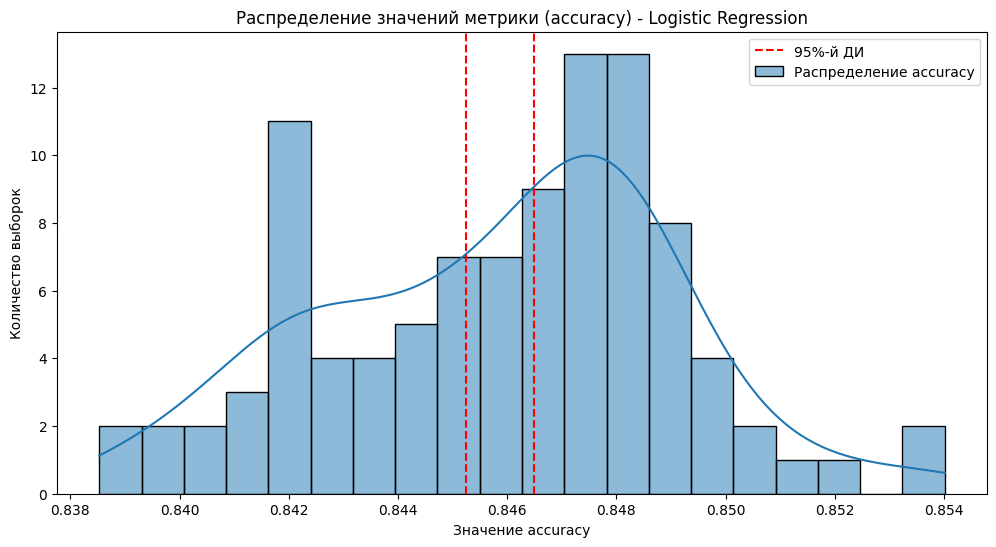

Ширина DI (LR): 0.0012407610155856785


In [49]:
ci = sps.bootstrap((lr_dist,), np.mean, confidence_level=0.95).confidence_interval

plt.figure(figsize=(12, 6))
plt.title("Распределение значений метрики (accuracy) - Logistic Regression")
plt.xlabel("Значение accuracy")
plt.ylabel("Количество выборок")
sns.histplot(x=lr_dist, bins=20, kde=True, label="Распределение accuracy")
plt.axvline(ci.low, color="red", linestyle="--", label="95%-й ДИ")
plt.axvline(ci.high, color="red", linestyle="--")
plt.legend()
plt.show()

print(f"Ширина DI (LR): {ci.high - ci.low}")

In [37]:
n_boostrap = 50
n_samples = X_train.shape[0]

dt_dist = np.zeros(n_boostrap)

for i in tqdm(range(n_boostrap)):
  train_idx = np.random.choice(n_samples, size=n_samples, replace=True)
  X_boot = X_train.iloc[train_idx]
  y_boot = y_train.iloc[train_idx]

  val_idx = np.setdiff1d(np.arange(n_samples), train_idx)
  X_val = X_train.iloc[val_idx]
  y_val = y_train.iloc[val_idx]

  dt_model_calibrated.fit(X_boot, y_boot)
  dt_dist[i] = accuracy_score(y_val, dt_model_calibrated.predict(X_val))

100%|██████████| 50/50 [16:34<00:00, 19.88s/it]


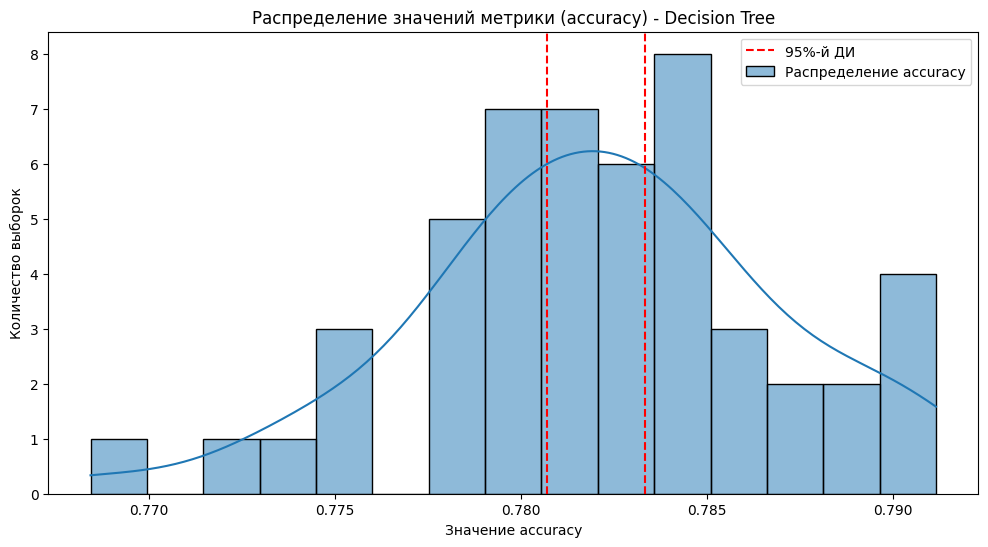

Ширина DI (LR): 0.002643937243659633


In [46]:
ci = sps.bootstrap((dt_dist,), np.mean, confidence_level=0.95).confidence_interval

plt.figure(figsize=(12, 6))
plt.title("Распределение значений метрики (accuracy) - Decision Tree")
plt.xlabel("Значение accuracy")
plt.ylabel("Количество выборок")
sns.histplot(x=dt_dist, bins=15, kde=True, label="Распределение accuracy")
plt.axvline(ci.low, color="red", linestyle="--", label="95%-й ДИ")
plt.axvline(ci.high, color="red", linestyle="--")
plt.legend()
plt.show()

print(f"Ширина DI (LR): {ci.high - ci.low}")

## Задание 6 [1 балл]

Проверь и сравни модели.

1. Сравни две обученные модели по ширине доверительного интервала — **[0,5 балла]**.
2. Напиши вывод: можно ли уверенно сказать, что одна модель лучше другой? — **[0,5 балла]**.


1. Ширина ДИ интервала меньше у `Logistic Regression` чем у `Decision Tree`, разница составляет порядка $\sim10^{-4}=0.01\%$
2. Разница между нижней (`LR`) и верхней (`DT`) границей ДИ составляет $>5\%$, что однозначно нам говорит о преимуществе метода **логистической регрессии**.